## Load news data


In [16]:
import pandas as pd
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import pytextrank
import nltk


/home/haile/haile's/kifiya/week1/.venv/lib/python3.13/site-packages


#### TextBlob is a Python library for Natural Language Processing (NLP).
#### It can do sentiment analysis, part-of-speech tagging, noun phrase extraction, translation, and more.

In [ ]:
import pandas as pd

data = pd.read_csv("../Data/newsData/raw_analyst_ratings.csv", index_col=0)  # index_col=0 ignores Unnamed:0
print(data.head())
print(data.columns)

                                            headline  \
0            Stocks That Hit 52-Week Highs On Friday   
1         Stocks That Hit 52-Week Highs On Wednesday   
2                      71 Biggest Movers From Friday   
3       46 Stocks Moving In Friday's Mid-Day Session   
4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20/06/16190091/s...  Benzinga Insights   
1  https://www.benzinga.com/news/20/06/16170189/s...  Benzinga Insights   
2  https://www.benzinga.com/news/20/05/16103463/7...         Lisa Levin   
3  https://www.benzinga.com/news/20/05/16095921/4...         Lisa Levin   
4  https://www.benzinga.com/news/20/05/16095304/b...         Vick Meyer   

                        date stock  
0  2020-06-05 10:30:54-04:00     A  
1  2020-06-03 10:45:20-04:00     A  
2  2020-05-26 04:30:07-04:00     A  
3  2020-05-22 12:45:06-04:00     A  
4  2020-05-22 11:38:59-04:0

In [9]:
# Clean stock data

# Remove rows with missing values
data = data.dropna()

# Ensure correct data types
for col in ['Open','High','Low','Close','Volume']:
    data[col] = data[col].astype(float)


In [10]:
# Calculate the Moving Average
data['MA20'] = data['Close'].rolling(window=20).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

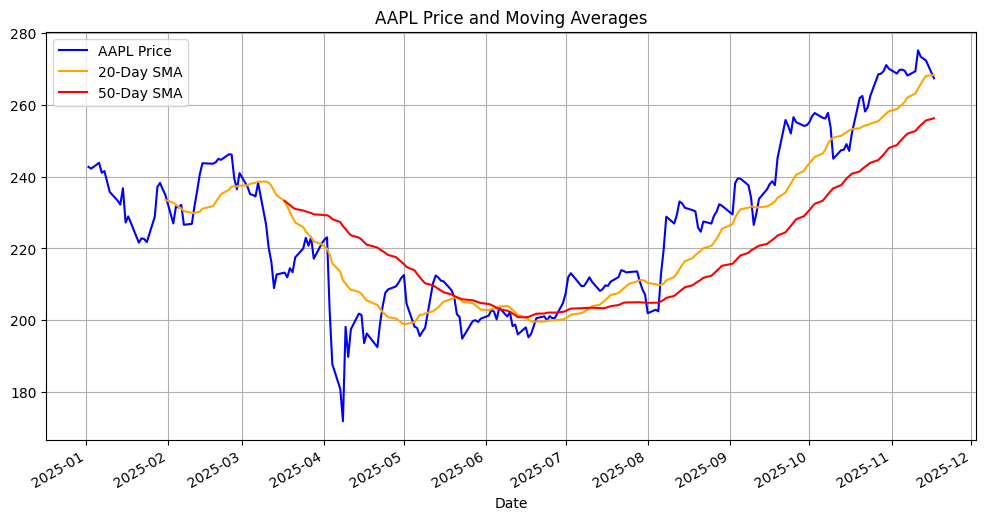

In [11]:
# --- 4. Visualization (Showing TA) ---
plt.figure(figsize=(12, 6))
data[('Close')].plot(label='AAPL Price', color='blue') 
data['MA20'].plot(label='20-Day SMA', color='orange')
data['MA50'].plot(label='50-Day SMA', color='red')
plt.title('AAPL Price and Moving Averages')
plt.legend()
plt.grid(True)
plt.show()